# Motion Model Examples

# Table of Contents

# Table of Contents
- [1. Motion Model](#1-motion-model)
   - [1.1. Example: Linear Model Fit](#11-example-linear-model-fit)
   - [1.2. Example: Acceleration Model Fit](#12-example-acceleration-model-fit)
   - [1.3. Example: Parallax Model Fit](#13-example-parallax-model-fit)
- [2. Fit Motion Model in StarTable](#2-fit-motion-model-in-startable)
  - [2.1. Example: Default Fitting](#21-example-default-fitting)
  - [2.2 Example: Specify Motion Models](#22-example-specify-motion-models)
  - [2.3. Example: Specify the `motion_model_input` Column](#23-example-specify-the-motion_model_input-column)
  - [2.4. Example: Infer Positions](#24-example-infer-positions)
  - [2.5. Speed Test](#25-speed-test)


# 1. Motion Model

Summary of currently implemented motion models

| Motion Model | n_params | params                                     | fixed_params                                                                                                | model                                                       | Description                                                                                                                                                                |
|--------------|----------|--------------------------------------------|-------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Empty        | 0        | NA                                         | NA                                                                                                          | $x(t) = $ NaN / fill_value<br>$x_e(t) = $ Inf               |                                                                                                                                                                            |
| Fixed        | 1        | $x_0$ <br> $y_0$                           | NA                                                                                                          | $x(t) = $ np.average($x$, weights=$x_{wt}$)                 | $x_{wt} = 1/xe^2$ if weighting='var'<br>$x_{wt} = 1/\|xe\|$ if weighting = 'std'                                                                                           |
| Linear       | 2        | $x_0, v_x$ <br> $y_0, v_y$                 | optional: $t_0 =$ np.average($t, 1/\sqrt{x_e^2 + y_e^2}$)                                                   | $x(t) = x_0 + v_x * (t - t_0)$                              |                                                                                                                                                                            |
| Acceleration | 3        | $x_0, v_{x0}, a_x$ <br> $y_0, v_{y0}, a_y$ | optional: $t_0 =$ np.average($t, 1/\sqrt{x_e^2 + y_e^2}$)                                                   | $x(t) = x_0 + v_{x0} * (t - t_0) + 1/2 * a_x * (t - t_0)^2$ |                                                                                                                                                                            |
| Parallax     | 3        | $x_0, v_x, pi$<br>$y_0, v_y$               | required: ra, dec<br>optional: $t_0 =$ np.average($t, 1/\sqrt{x_e^2 + y_e^2}$); $pa=0$; obsLocation='earth' | $x(t) = x_0 + v_x * (t - t_0) + pvec * (t - t_0)$           | pvec is the parallax vector calculated based on ra, dec, pa, and obsLocation.<br>Only supports the same obsLocation for all stars in StarTable.fit_motion_model right now. |

Examples on using `flystar.MotionModel`:

In [1]:
%load_ext autoreload
%autoreload 2

Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from flystar import motion_model
from flystar.startables import StarTable
from flystar.motion_model import Empty, Fixed, Linear, Acceleration, Parallax

Prepare data

In [11]:
t = np.array([0, 1., 2.2, 3.5, 5.]) + 2025.0
x = np.array([0., 0.5, 2.1, 3.2, 8.0])
y = np.array([10.2, 8.5, 9.1, 10.5, 13.0])
xe = np.array([0.2, 0.5, 0.3, 0.4, 0.6])
ye = np.array([0.3, 0.2, 0.5, 0.2, 0.4])
t_test = np.linspace(2025.0, 2030.0, 100)   # Test times for model evaluation

## 1.1. Example: Linear Model Fit

In [12]:
mm = Linear()
params, param_errs = mm.fit(t, x, y, xe, ye)

Evaluate model at time t:

In [13]:
x_model, y_model = mm.model(t, params)

Or if uncertainties of parameters is provided at the same time, the model will return the model uncertainties as well:

In [14]:
x_model, y_model, xe_model, ye_model = mm.model(t, params, param_errs)

Note that we did not provide the `fixed_params_dict` parameter in the `model` function, so the MotionModel will use the saved self.fixed_params_dict. One can also specify the fixed_params_dict as:

In [15]:
mm.fixed_params_dict

{'t0': np.float64(2027.0454838983064)}

In [21]:
x_model, y_model, xe_model, ye_model = mm.model(t_test, params, param_errs, mm.fixed_params_dict)

Define a helper function to visualize result

In [24]:
def visualize_fit(t, x, y, xe, ye, x_model, y_model, xe_model, ye_model, mm_name, t_test=None):
    if t_test is None:
        t_test = t
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)
    xe = np.atleast_2d(xe)
    ye = np.atleast_2d(ye)
    x_model = np.atleast_2d(x_model)
    y_model = np.atleast_2d(y_model)
    xe_model = np.atleast_2d(xe_model)
    ye_model = np.atleast_2d(ye_model)
    
    N_cases = x.shape[0]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    for i in range(N_cases):
        l0 = ax1.errorbar(t, x[i], yerr=xe[i], fmt='o', color=f'C{i%10}', label='Data')
        l1, = ax1.plot(t_test, x_model[i], label=f'{mm_name} Fit')
        l2 = ax1.fill_between(t_test, x_model[i] - xe_model[i], x_model[i] + xe_model[i], color=f'C{i%10}', alpha=0.3, label='Model Uncertainty')

        r0 = ax2.errorbar(t, y[i], yerr=ye[i], fmt='o', color=f'C{i%10}', label='Data')
        r1, = ax2.plot(t_test, y_model[i], label=f'{mm_name} Fit')
        r2 = ax2.fill_between(t_test, y_model[i] - ye_model[i], y_model[i] + ye_model[i], color=f'C{i%10}', alpha=0.3, label='Model Uncertainty')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('X Position')
    ax1.set_title(f'{mm_name} Motion Model Fit')
    ax1.legend(
        [l0, (l1, l2)], 
        ['Data', 'Model Fit'],
    )
    
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Y Position')
    ax2.set_title(f'{mm_name} Motion Model Fit')
    ax2.legend(
        [r0, (r1, r2)], 
        ['Data', 'Model Fit'],
    )
    plt.tight_layout()
    plt.show()

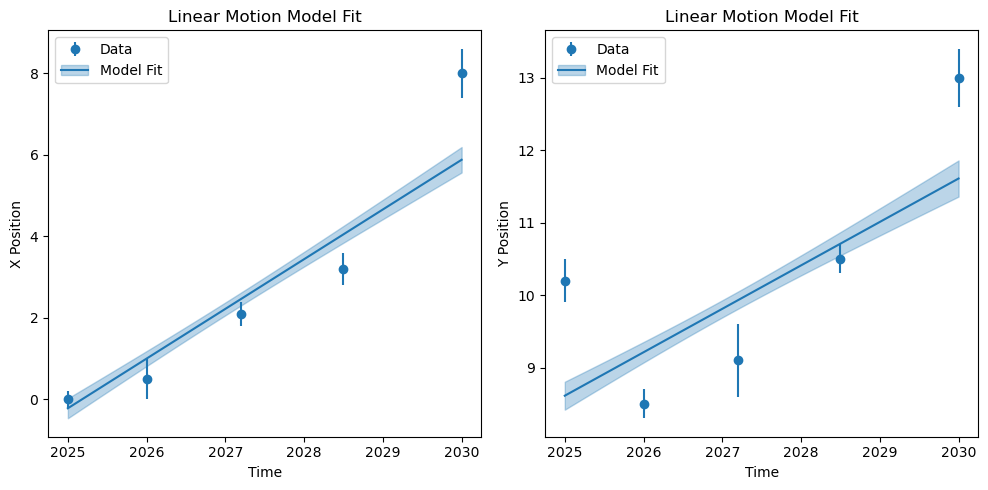

In [26]:
visualize_fit(t, x, y, xe, ye, x_model, y_model, xe_model, ye_model, mm.name, t_test)

## 1.2. Example: Acceleration Model Fit

Upon further inspection, acceleration model seems to be a better representation of the data

In [27]:
mm = Acceleration()
params, param_errs = mm.fit(t, x, y, xe, ye)

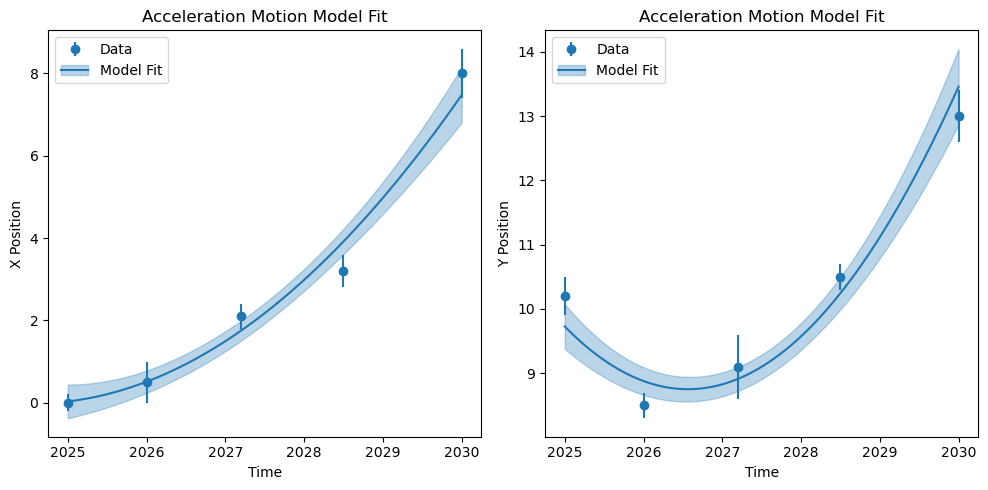

In [28]:
x_model, y_model, xe_model, ye_model = mm.model(t_test, params, param_errs)
visualize_fit(t, x, y, xe, ye, x_model, y_model, xe_model, ye_model, mm.name, t_test)

Moreover, `MotionModel.model` is fully vectorized, and can infer positions of multiple stars at multiple times, and the resulting inferred positions has shape (N_stars, N_times). See the example below:

In [29]:
t = np.array([0, 1., 2.2, 3.5, 5.]) + 2025.0

xs = np.array([
    [0., 0.5, 2.1, 3.2, 8.0],
    [10.0, 8.9, 9.2, 7.4, 7.0],
    [2.5, 6.2, 5.2, 3.2, 5.0]
])

ys = np.array([
    [10.2, 8.5, 9.1, 10.5, 13.0],
    [8.0, 9.9, 8.2, 7.4, 7.0],
    [5.2, 6.2, 4.7, 3.2, 6.0]
])

xes = np.array([
    [0.2, 0.5, 0.3, 0.4, 0.6],
    [0.5, 0.2, 0.7, 0.3, 0.2],
    [0.5, 0.7, 0.6, 0.4, 0.3]
])

yes = np.array([
    [0.3, 0.2, 0.5, 0.2, 0.4],
    [0.2, 0.5, 0.6, 0.4, 0.2],
    [0.4, 0.2, 0.3, 0.4, 0.5]
])

In [30]:
params = []
param_errs = []
for xi, yi, xei, yei in zip(xs, ys, xes, yes):
    p, pe = mm.fit(t, xi, yi, xei, yei)
    params.append(p)
    param_errs.append(pe)

Once we have the params and param errors, we can infer the model positions at any given time.

In [31]:
x_model, y_model, xe_model, ye_model = mm.model(t_test, params, param_errs)

The inferred positions should have shape (N_stars, N_times):

In [32]:
x_model.shape

(3, 100)

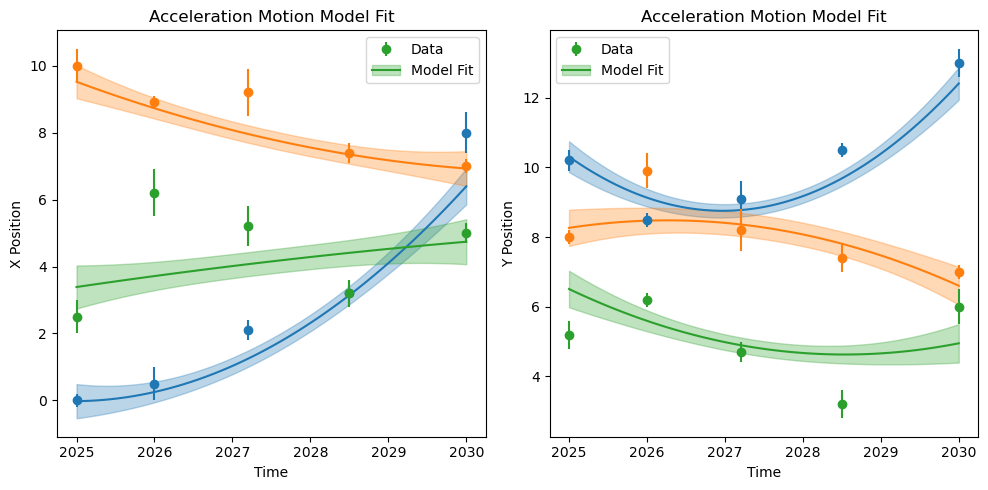

In [33]:
visualize_fit(t, xs, ys, xes, yes, x_model, y_model, xe_model, ye_model, mm.name, t_test)

## 1.3. Example: Parallax Model Fit

Parallax model requires some fixed parameters: `ra`, `dec`, `pa`, `obsLocation`, and `t0`.
- `ra` and `dec` are required parameters. 
- `pa = 0` by default
- `obsLocation = 'earth'` by default
- `t0 = np.average(t, 1./np.hypot(xe, ye))` by default

We need to provide the fixed parameters in the `fixed_params_dict`:

In [34]:
mm = Parallax()
fixed_params_dict = {'ra': 0., 'dec': 10., 'pa': 0., 'obsLocation': 'earth'}
params, param_errs = mm.fit(t, x, y, xe, ye, fixed_params_dict)

/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 2 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 2 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/pytho

/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 20 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 40 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 40 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 20 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/p

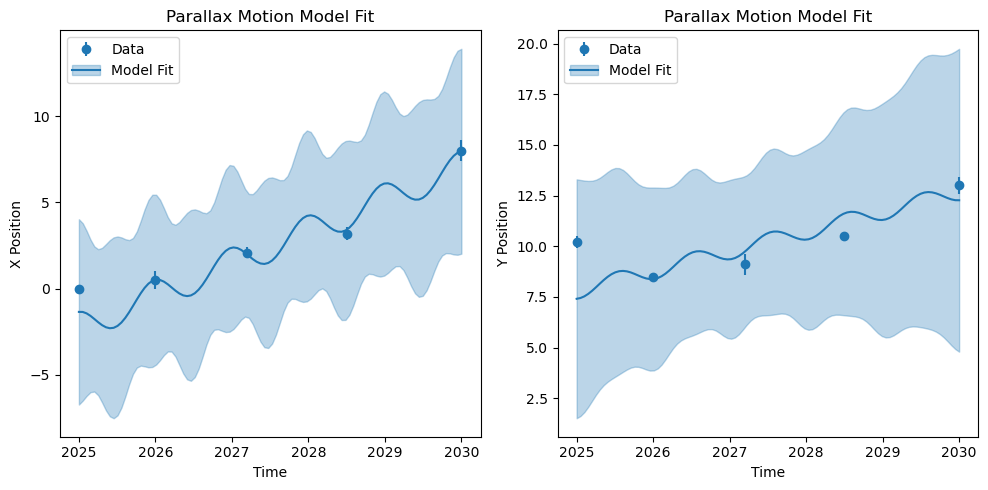

In [35]:
x_model, y_model, xe_model, ye_model = mm.model(t_test, params, param_errs)
visualize_fit(t, x, y, xe, ye, x_model, y_model, xe_model, ye_model, mm.name, t_test)

# 2. Fit Motion Model in StarTable

Examples on `flystar.StarTable.fit_motion_model`. Prepare the data with invalid values:

In [36]:
t = np.array([0, 1., 2.2, 3.5, 5.]) + 2025.0

x = np.array([
    [0., 0.5, 2.1, 3.2, 8.0],                   # Increasing 5 Epochs
    [10.0, 8.9, 9.2, 7.4, 7.0],                 # Decreasing 5 Epochs
    [2.5, np.nan, 5.2, np.nan, 5.0],            # 3 Epochs
    [np.nan, 6.2, np.nan, np.nan, 9.2],         # 2 Epochs
    [np.nan, 2.0, np.nan, np.nan, np.nan],      # 1 Epoch
    [np.nan, np.nan, np.nan, np.nan, np.nan]    # All NaNs
])

y = np.array([
    [10.2, 8.5, 9.1, 10.5, 13.0],               # Increasing 5 Epochs
    [8.0, 9.9, 8.2, 7.4, 7.0],                  # Decreasing 5 Epochs
    [5.2, np.nan, 4.7, np.nan, 6.0],            # 3 Epochs
    [np.nan, 1.2, np.nan, np.nan, 3.2],         # 2 Epochs
    [np.nan, 2.0, np.nan, np.nan, np.nan],      # 1 Epoch
    [np.nan, np.nan, np.nan, np.nan, np.nan]    # All NaNs
])

xe = np.array([
    [0.2, 0.5, 0.3, 0.4, 0.6],
    [0.5, 0.2, 0.7, 0.3, 0.2],
    [0.5, np.nan, 0.6, np.nan, 0.3],
    [np.nan, 0.6, np.nan, np.nan, 0.3],
    [np.nan, 0.4, np.nan, np.nan, np.nan],
    [np.nan, np.nan, np.nan, np.nan, np.nan]
])

ye = np.array([
    [0.3, 0.2, 0.5, 0.2, 0.4],
    [0.2, 0.5, 0.6, 0.4, 0.2],
    [0.7, np.nan, 0.5, np.nan, 0.2],
    [np.nan, 0.4, np.nan, np.nan, 0.5],
    [np.nan, 0.5, np.nan, np.nan, np.nan],
    [np.nan, np.nan, np.nan, np.nan, np.nan]
])

x = np.ma.masked_invalid(x)
y = np.ma.masked_invalid(y)
xe = np.ma.masked_invalid(xe)
ye = np.ma.masked_invalid(ye)
mask = np.ma.getmaskarray(x) | np.ma.getmaskarray(y) | np.ma.getmaskarray(xe) | np.ma.getmaskarray(ye)

tab = StarTable({
    'x': x,
    'y': y,
    'xe': xe,
    'ye': ye
})
tab.meta['list_times'] = t

There are a 2 ways to specify the desired motion models:
1. Let MotionModel automatically determine which motion model to use among the given `motion_models` list based on the number of valid observations. MotionModel will choose the motion model that has enough observations, i.e. $n_\text{fit} \geq n_\text{params}$. 
2. Specify a motion model for each star in the `motion_model_input` column. In case there is not enough observations, MotionModel will "downgrade" to a model with less parameters until $n_\text{fit} \geq n_\text{params}$ among all the unique motion models specified in the column.

Note that when `absolute_sigma=False` and `n_fit == n_params`, we don't have enough degree of freedom to rescale the uncertainties, so the uncertainties will be set to infinity -- the same behavior as `scipy.optimize.curve_fit`.<br> By default `motion_models = [Empty, Fixed, Linear]`. `Empty` and `Fixed` will always be added in the list to handle 0 and 1 point cases. See examples below for details. Let's start with the most basic usage.

## 2.1. Example: Default Fitting

In [37]:
tab.fit_motion_model()

Fitting motion model Empty:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:119: OptimizeWarning: Empty data cannot be fit. Setting parameters to nan and uncertainties to np.inf.
  fit_result = self.run_fit(
Fitting motion model Fixed:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:404: UserWarning: Fixed model has no non-scipy fitter option. Running with scipy.
  warnings.warn("Fixed model has no non-scipy fitter option. Running with scipy.")
Fitting motion model Linear: 100%|██████████| 4/4 [00:00<00:00, 7040.38it/s]


Since we do not specify the `motion_models` parameter in the `fit_motion_model` function, the default motion model of `Empty`, `Fixed` and `Linear` will be used. The function automatically determines which motion models among the three to use based on the number of valid observations, i.e., $n_\text{fit} \geq n_\text{params}$:

In [38]:
tab['n_required'] = 2
tab[['n_fit', 'n_required', 'motion_model_used']]

n_fit,n_required,motion_model_used
int64,int64,str20
5,2,Linear
5,2,Linear
3,2,Linear
2,2,Linear
1,2,Fixed
0,2,Empty


Next, let's try `absolute_sigma=False`. As mentioned above, we don't have enough degree of freedom to rescale the uncertainties for the forth star. In this case, the parameter uncertainties will be set to infinity, which is the same behavior as `scipy.optimize.curve_fit`. The same `OptmizieWarning` as in `scipy` will be raised.

In [21]:
tab.fit_motion_model(absolute_sigma=False)

Fitting motion model Empty:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:119: OptimizeWarning: Empty data cannot be fit. Setting parameters to nan and uncertainties to np.inf.
  fit_result = self.run_fit(
Fitting motion model Fixed:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:404: UserWarning: Fixed model has no non-scipy fitter option. Running with scipy.
  warnings.warn("Fixed model has no non-scipy fitter option. Running with scipy.")
/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:119: OptimizeWarning: Degree of freedom < 0. Covariance of the parameters could not be estimated. Setting parameter uncertainties to fill value np.inf.
  fit_result = self.run_fit(
Fitting motion model Linear: 100%|██████████| 4/4 [00:00<00:00, 4723.32it/s]


In [22]:
tab['vx_err']

0.2398025689409276
0.07197698078673948
0.26723109004421475
inf
inf
inf


## 2.2. Example: Specify Motion Models

Alternatively, one can specify a list of motion models to use, and the function will also automatically determine which model to use for each star depending on the valid observed epochs. In the following example, we specify `Acceleration` model, but **the function will always implicitly add `Empty` and `Fixed`** to handle the 0 or 1 epoch stars.

In [23]:
tab.fit_motion_model(motion_models=['Acceleration'])

Fitting motion model Acceleration:   0%|          | 0/3 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:785: UserWarning: Acceleration model has no non-scipy fitter option. Running with scipy.
  warnings.warn("Acceleration model has no non-scipy fitter option. Running with scipy.")
Fitting motion model Fixed: 100%|██████████| 2/2 [00:00<00:00, 10754.63it/s]


In [24]:
tab[['n_fit', 'motion_model_used']]

n_fit,motion_model_used
int64,str20
5,Acceleration
5,Acceleration
3,Acceleration
2,Fixed
1,Fixed
0,Empty


## 2.3. Example: Specify the `motion_model_input` Column

One can also specify a motion model for each star as a column in the star table. However, the function will "downgrade" the model to one with fewer parameters until $n_\text{fit} \geq n_\text{params}$:

In [39]:
ra = np.zeros(len(x))
dec = np.zeros(len(x))
pa = np.zeros(len(x))

motion_model_input = [
    'Acceleration', # Will use Acceleration
    'Parallax',     # Will use Parallax
    'Linear',       # Will use Linear
    'Acceleration', # Will use Linear, as n_fit = 2 < 3
    'Linear',       # Will use Fixed, as n_fit = 1 < 2
    'Fixed'         # Will use Empty, as n_fit = 0 < 1
]
tab = StarTable({
    'x': x,
    'y': y,
    'xe': xe,
    'ye': ye,
    'ra': ra,
    'dec': dec,
    'pa': pa,
    'motion_model_input': motion_model_input
})
tab.meta['list_times'] = t

In [40]:
tab.fit_motion_model(fixed_params_dict={
    'ra': ra, 
    'dec': dec, 
    'pa': pa,
    'obsLocation': 'earth'
})

Fitting motion model Acceleration:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:785: UserWarning: Acceleration model has no non-scipy fitter option. Running with scipy.
  warnings.warn("Acceleration model has no non-scipy fitter option. Running with scipy.")
Fitting motion model Empty:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:119: OptimizeWarning: Empty data cannot be fit. Setting parameters to nan and uncertainties to np.inf.
  fit_result = self.run_fit(
Fitting motion model Empty: 100%|██████████| 1/1 [00:00<00:00, 9258.95it/s]


Fitting motion model Fixed:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:404: UserWarning: Fixed model has no non-scipy fitter option. Running with scipy.
  warnings.warn("Fixed model has no non-scipy fitter option. Running with scipy.")
Fitting motion model Parallax:   0%|          | 0/1 [00:00<?, ?it/s]/Users/weilingfeng/Academic/Software/flystar/flystar/motion_model.py:1002: UserWarning: Parallax model has no non-scipy fitter option. Running with scipy.
  warnings.warn("Parallax model has no non-scipy fitter option. Running with scipy.", UserWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 2 of

Let's check if the actually used motion model is corrected:

In [41]:
all_mm_map = motion_model.motion_model_map()
tab['n_required'] = np.array([all_mm_map[mm].n_params for mm in tab['motion_model_input']], dtype=int)
tab[['n_fit', 'n_required', 'motion_model_input', 'motion_model_used']]

n_fit,n_required,motion_model_input,motion_model_used
int64,int64,str12,str12
5,3,Acceleration,Acceleration
5,3,Parallax,Parallax
3,2,Linear,Linear
2,3,Acceleration,Linear
1,2,Linear,Fixed
0,1,Fixed,Empty


## 2.4. Example: Infer Positions

Continuing from the previous example: Once we fit the motion models and the parameters are added into the table, we can infer the positions at arbitrary times with `StarTable.infer_positions`

In [42]:
x_model, y_model, xe_model, ye_model = tab.infer_positions(t_test)

/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 20 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 40 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 40 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 20 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/weilingfeng/Software/miniconda3/envs/main/lib/p

As in `MotionModel.model`, `StarTable.infer_positions` is also vectorized and returns positions and uncertainties in shapes of $(N_\text{stars}, N_\text{times})$

In [44]:
x_model.shape

(6, 100)

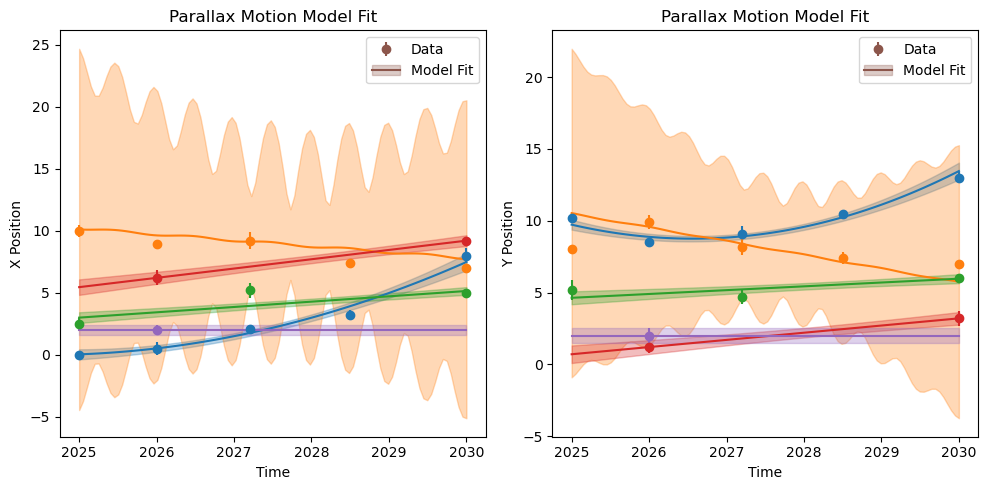

In [29]:
visualize_fit(t, x, y, xe, ye, x_model, y_model, xe_model, ye_model, mm.name, t_test)

## 2.5. Speed Test

Speed test for the most commonly used Linear model. As the `use_scipy=False` option for the Linear model uses the [matrix multiplication solution](https://en.wikipedia.org/wiki/Weighted_least_squares#Solution), it is extremely fast at fewer epochs: 

In [30]:
import time
N = 10000
dims = np.logspace(1, 3, 5, dtype=int)
rng = np.random.default_rng(42)

scipy_times = []
analytic_times = []

for dim in dims:
    print(f'Fitting {dim} epochs...')
    t = np.linspace(2025.0, 2030.0, dim)
    x = rng.random((N, dim))
    y = rng.random((N, dim))
    xe = rng.uniform(0, 0.2, size=(N, dim))
    ye = rng.uniform(0, 0.2, size=(N, dim))
    tab = StarTable({
        'x': x,
        'y': y,
        'xe': xe,
        'ye': ye
    })
    tab.meta['list_times'] = t
    
    start = time.time()
    tab.fit_motion_model(use_scipy=True)
    end = time.time()
    scipy_times.append(end - start)
    
    start = time.time()
    tab.fit_motion_model(use_scipy=False)
    end = time.time()
    analytic_times.append(end - start)

scipy_times = np.array(scipy_times)
analytic_times = np.array(analytic_times)
    

Fitting 10 epochs...


Fitting motion model Linear: 100%|██████████| 10000/10000 [00:00<00:00, 25802.05it/s]


Fitting 31 epochs...


Fitting motion model Linear: 100%|██████████| 10000/10000 [00:00<00:00, 23908.79it/s]


Fitting 100 epochs...


Fitting motion model Linear: 100%|██████████| 10000/10000 [00:00<00:00, 14309.49it/s]


Fitting 316 epochs...


Fitting motion model Linear: 100%|██████████| 10000/10000 [00:03<00:00, 3288.47it/s]


Fitting 1000 epochs...


Fitting motion model Linear: 100%|██████████| 10000/10000 [01:19<00:00, 125.47it/s]


In [31]:
# Collect memory garbage data
import gc
gc.collect()

280

Let's visualize the performance:

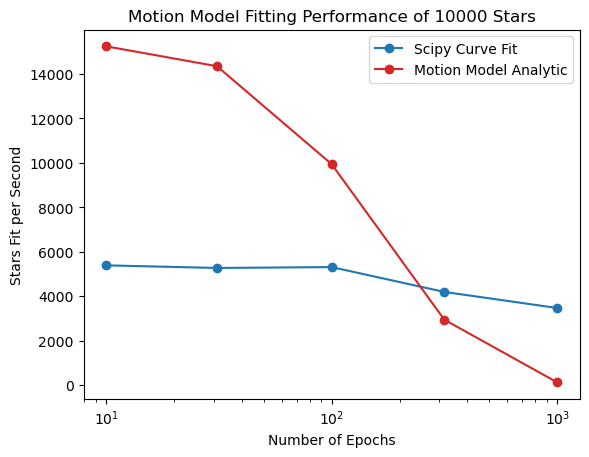

In [32]:
fig, ax = plt.subplots()
ax.plot(dims, N / scipy_times, marker='o', label='Scipy Curve Fit')
ax.plot(dims, N / analytic_times, marker='o', color='C3', label='Motion Model Analytic')
ax.set_xscale('log')
ax.set_xlabel('Number of Epochs')
ax.set_ylabel('Stars Fit per Second')
ax.set_title(f'Motion Model Fitting Performance of {N} Stars')
ax.legend()
plt.show()

It can be seen that for epochs < 200, the analytic solution is faster than scipy, and vice versa for > 300 epochs.